In [72]:
import numpy as np
import matplotlib.pyplot as plt

from simple_autoencoder import Autoencoder

## Pomoćne funkcije

In [67]:
def loss_function(y_pred, y_true):
    diff = y_pred - y_true
    batch_size = y_pred.shape[0]

    loss = 0.5 * np.mean(np.sum(diff * diff, axis=1))
    mse = np.mean(diff * diff)

    grad = diff / batch_size

    return loss, mse, grad.astype(np.float32)


def add_gaussian_noise(x, noise_std=0.15, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    noise = rng.normal(0.0, noise_std, size=x.shape).astype(np.float32)
    return (x + noise).astype(np.float32)

def mask_random_signal_part(x, mask_size=256, rng=None, return_mask=False):
    if rng is None:
        rng = np.random.default_rng()

    x_masked = x.copy().astype(np.float32)
    batch_size, signal_length = x_masked.shape

    if mask_size >= signal_length:
        x_masked[:] = 0.0
        mask = np.zeros_like(x_masked, dtype=np.float32)
        return (x_masked, mask) if return_mask else x_masked

    mask = np.ones_like(x_masked, dtype=np.float32)

    for i in range(batch_size):
        start = rng.integers(0, signal_length - mask_size + 1)
        end = start + mask_size

        x_masked[i, start:end] = 0.0
        mask[i, start:end] = 0.0

    return (x_masked, mask) if return_mask else x_masked

In [69]:
def make_sine_dataset(n_examples, signal_length=2048, sample_rate=16000, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)

    t = np.arange(signal_length, dtype=np.float32) / sample_rate
    X = np.zeros((n_examples, signal_length), dtype=np.float32)

    allowed_freqs = np.array([220.0, 330.0, 440.0, 660.0, 880.0], dtype=np.float32)

    for i in range(n_examples):
        x = np.zeros(signal_length, dtype=np.float32)
        
        n_tones = rng.integers(1, 3)
        freqs = rng.choice(allowed_freqs, size=n_tones, replace=False)

        for freq in freqs:
            phase = rng.uniform(0.0, 2.0 * np.pi)
            amp = rng.uniform(0.5, 1.0)

            x += amp * np.sin(2.0 * np.pi * freq * t + phase)

        x *= np.hanning(signal_length).astype(np.float32)
        x /= np.max(np.abs(x)) + 1e-8

        X[i] = x

    return X


def sample_batch(X, batch_size, rng):
    idx = rng.integers(0, X.shape[0], size=batch_size)
    return X[idx]

In [73]:
def plot_signals(
    x_clean,
    x_noisy,
    x_reconstructed,
):
    cmap = plt.get_cmap("Paired")

    clean_color = cmap(1)
    noisy_color = cmap(5)
    reconstructed_color = cmap(3)

    noisy_error_color = noisy_color
    reconstruction_error_color = reconstructed_color

    noisy_error = x_noisy - x_clean
    reconstruction_error = x_reconstructed - x_clean

    max_amp = max(
        np.max(np.abs(x_clean)),
        np.max(np.abs(x_noisy)),
        np.max(np.abs(x_reconstructed)),
    )
    offset = 2.5 * max_amp

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(12, 7),
        sharex=True,
        gridspec_kw={"height_ratios": [2, 1]},
    )

    axes[0].plot(x_clean + offset, color=clean_color)
    axes[0].plot(x_noisy, color=noisy_color)
    axes[0].plot(x_reconstructed - offset, color=reconstructed_color)

    axes[0].set_yticks([offset, 0, -offset])
    axes[0].set_yticklabels(["Original", "Dodan šum", "Rekonstrukcija"])
    axes[0].set_title("Signali")

    axes[1].plot(noisy_error, label="Šumovit - Original", alpha=0.6, color=noisy_error_color)
    axes[1].plot(reconstruction_error, label="Rekonstrukcija - Original", color=reconstruction_error_color)
    axes[1].axhline(0, linestyle="--", linewidth=1)

    axes[1].set_title("Greška u odnosu na originalni signal")
    axes[1].set_xlabel("Uzorak")
    axes[1].set_ylabel("Greška")
    axes[1].legend(loc="upper right")

    plt.tight_layout()
    plt.show()

## Gaussovski šum

In [ ]:
rng = np.random.default_rng(42)

signal_length = 2048

X_train = make_sine_dataset(
    n_examples=3000,
    signal_length=signal_length,
    sample_rate=16000,
    rng=rng,
)

model = Autoencoder(
    signal_length=signal_length,
    hidden_dim=256,
    latent_dim=64,
    rng=rng,
)

batch_size = 32
noise_std = 0.15
lr = 1e-3
num_steps = 2000

for step in range(1, num_steps + 1):
    x_clean = sample_batch(X_train, batch_size, rng)
    x_noisy = add_gaussian_noise(x_clean, noise_std=noise_std, rng=rng)
    
    y_pred = model.forward(x_noisy)

    loss, mse, grad = loss_function(y_pred, x_clean)

    model.backward(grad)
    model.step(lr)

    if step % 100 == 0:
        print(f"step {step:5d} | loss {loss:10.4f} | mse {mse:.6f}")

step   100 | loss   111.6132 | mse 0.108997
step   200 | loss    57.0915 | mse 0.055753
step   300 | loss    20.0732 | mse 0.019603
step   400 | loss     8.9464 | mse 0.008737
step   500 | loss     5.8706 | mse 0.005733
step   600 | loss     4.9101 | mse 0.004795
step   700 | loss     4.0688 | mse 0.003973
step   800 | loss     3.9349 | mse 0.003843
step   900 | loss     3.5506 | mse 0.003467
step  1000 | loss     3.6315 | mse 0.003546
step  1100 | loss     3.2402 | mse 0.003164
step  1200 | loss     3.3014 | mse 0.003224
step  1300 | loss     3.3607 | mse 0.003282
step  1400 | loss     3.2820 | mse 0.003205
step  1500 | loss     2.7814 | mse 0.002716
step  1600 | loss     2.7970 | mse 0.002731
step  1700 | loss     3.1154 | mse 0.003042
step  1800 | loss     2.6735 | mse 0.002611
step  1900 | loss     2.7306 | mse 0.002667
step  2000 | loss     2.9225 | mse 0.002854


Corrupted MSE:      0.022430588
Reconstructed MSE:  0.0024073503


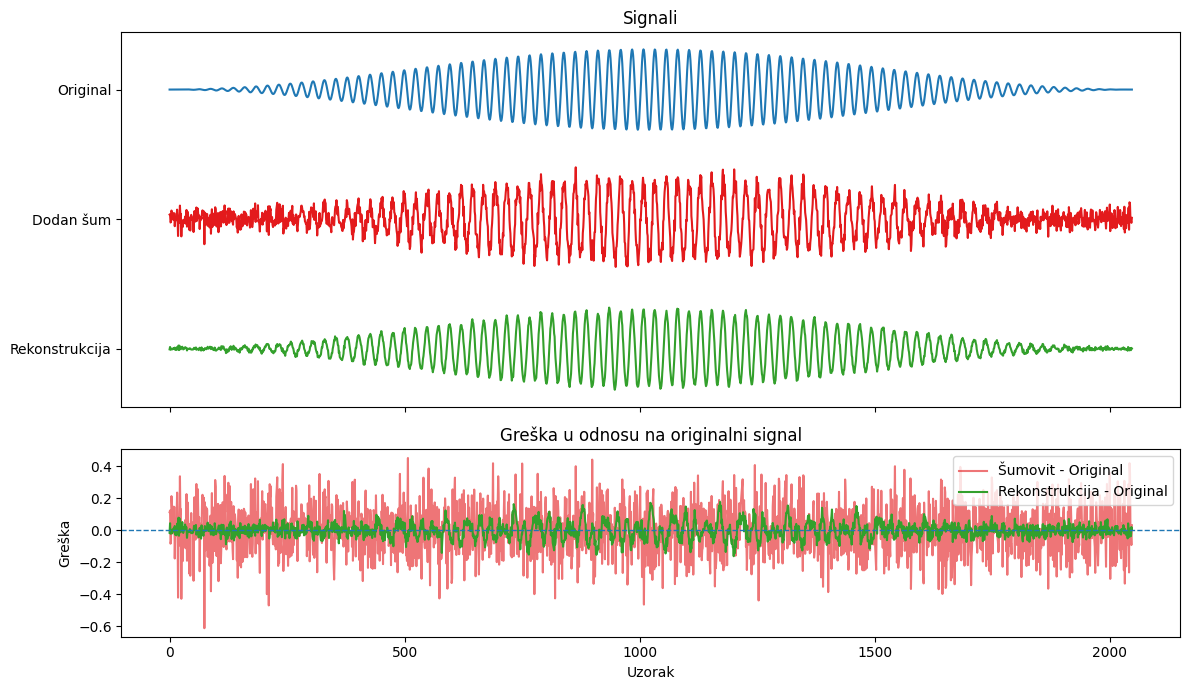

In [74]:
test_rng = np.random.default_rng(200)

x_clean = make_sine_dataset(
    n_examples=1,
    signal_length=2048,
    sample_rate=16000,
    rng=test_rng,
)

x_corrupted = add_gaussian_noise(x_clean, noise_std=0.15, rng=rng)

x_reconstructed = model.forward(x_corrupted)

corrupted_mse = np.mean((x_corrupted - x_clean) ** 2)
reconstructed_mse = np.mean((x_reconstructed - x_clean) ** 2)

print("Corrupted MSE:     ", corrupted_mse)
print("Reconstructed MSE: ", reconstructed_mse)

plot_signals(
    x_clean[0],
    x_corrupted[0],
    x_reconstructed[0]
)

## Nestali podaci

In [ ]:
rng = np.random.default_rng(42)

signal_length = 2048

X_train = make_sine_dataset(
    n_examples=3000,
    signal_length=signal_length,
    sample_rate=16000,
    rng=rng,
)

model = Autoencoder(
    signal_length=signal_length,
    hidden_dim=256,
    latent_dim=64,
    rng=rng,
)

batch_size = 32
noise_std = 0.15
lr = 1e-3
num_steps = 2000

for step in range(1, num_steps + 1):
    x_clean = sample_batch(X_train, batch_size, rng)
    x_noisy = mask_random_signal_part(
        x_clean,
        mask_size=128,
        rng=rng,
    )

    y_pred = model.forward(x_noisy)

    loss, mse, grad = loss_function(y_pred, x_clean)

    model.backward(grad)
    model.step(lr)

    if step % 100 == 0:
        print(f"step {step:5d} | loss {loss:10.4f} | mse {mse:.6f}")

step   100 | loss   109.0244 | mse 0.106469
step   200 | loss    55.5012 | mse 0.054200
step   300 | loss    24.3947 | mse 0.023823
step   400 | loss     9.1139 | mse 0.008900
step   500 | loss     5.5810 | mse 0.005450
step   600 | loss     3.9361 | mse 0.003844
step   700 | loss     3.0267 | mse 0.002956
step   800 | loss     2.7874 | mse 0.002722
step   900 | loss     2.4606 | mse 0.002403
step  1000 | loss     2.3067 | mse 0.002253
step  1100 | loss     1.8971 | mse 0.001853
step  1200 | loss     1.8831 | mse 0.001839
step  1300 | loss     1.6144 | mse 0.001577
step  1400 | loss     1.6333 | mse 0.001595
step  1500 | loss     1.5531 | mse 0.001517
step  1600 | loss     1.4894 | mse 0.001454
step  1700 | loss     1.4554 | mse 0.001421
step  1800 | loss     1.3822 | mse 0.001350
step  1900 | loss     1.5249 | mse 0.001489
step  2000 | loss     1.3644 | mse 0.001332


Corrupted MSE:      0.05943869
Reconstructed MSE:  0.0044380166


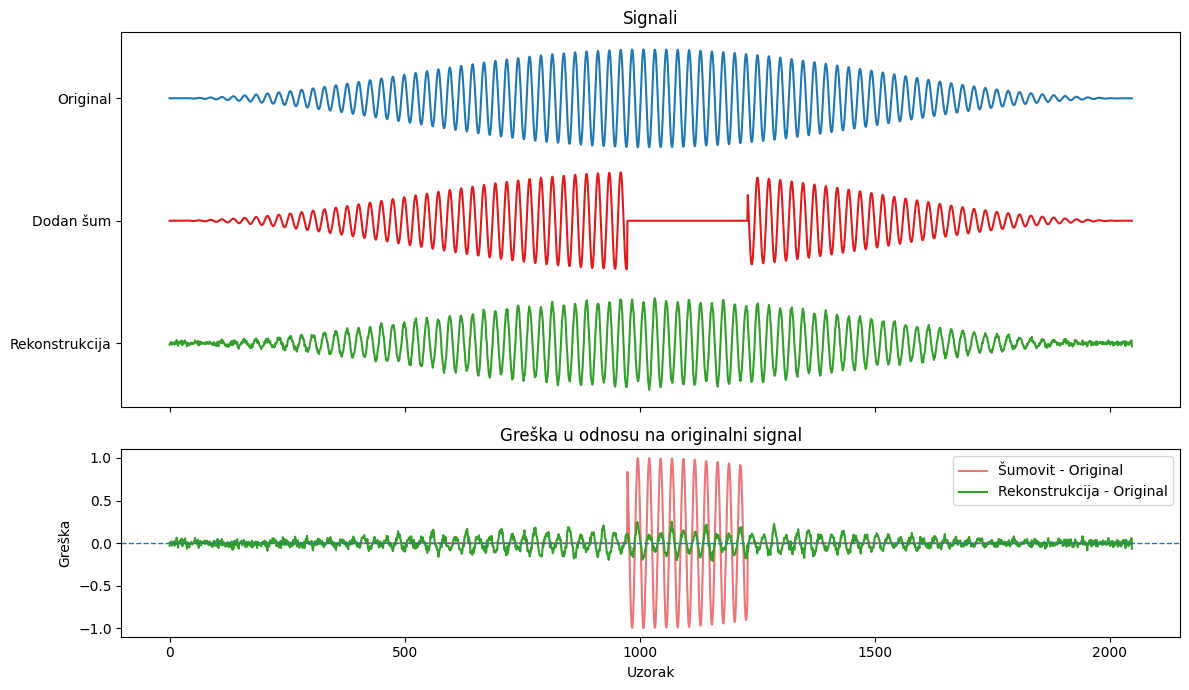

In [75]:
test_rng = np.random.default_rng(200)

x_clean = make_sine_dataset(
    n_examples=1,
    signal_length=2048,
    sample_rate=16000,
    rng=test_rng,
)

x_corrupted = mask_random_signal_part(
    x_clean,
    mask_size=256,
    rng=test_rng,
)

x_reconstructed = model.forward(x_corrupted)

corrupted_mse = np.mean((x_corrupted - x_clean) ** 2)
reconstructed_mse = np.mean((x_reconstructed - x_clean) ** 2)

print("Corrupted MSE:     ", corrupted_mse)
print("Reconstructed MSE: ", reconstructed_mse)

plot_signals(
    x_clean[0],
    x_corrupted[0],
    x_reconstructed[0]
)

In [ ]:
from IPython.display import display, Audio

display(Audio(x_clean[0], rate=16000))
display(Audio(x_corrupted[0], rate=16000))
display(Audio(x_reconstructed[0], rate=16000))